# Proyecto Kapak — Indicador 4: Detección de Preguntas Acusatorias
## Replica del pipeline de Roh López (2024) — 3 modelos seleccionados

Replica fiel del notebook `Proyecto_Final_MMIA_FRoh.ipynb`, restringida a los tres modelos del ensemble:

| Modelo | Algoritmo | Dataset | Embedding | Métricas de referencia |
|--------|-----------|---------|-----------|------------------------|
| **M1** — Equilibrado | Logistic Regression | `balanced_total_sinonimos` | text-embedding-3-large | AUC=0.940 · F1=0.677 · Recall=0.759 · Prec=0.611 |
| **M2** — Sensible | Naive Bayes | `total_augmented_data` | text-embedding-3-large | AUC=0.940 · F1=0.227 · Recall=1.000 · Prec=0.128 |
| **M3** — Conservador | Random Forest | `balanced_total_sentence_prompt_GPT4o_mini` | text-embedding-3-large | AUC=0.940 · F1=0.640 · Recall=0.552 · Prec=0.762 |

**Flujo principal:** los embeddings ya están pre-calculados → se cargan desde CSV → GridSearchCV → evaluación completa.

Las secciones de preprocesamiento y generación de embeddings se incluyen como **referencia** del pipeline original.

---
**Referencia:** Roh López, F. (2024). *Detección de comentarios acusatorios en procesos de contratación pública del Ecuador mediante aprendizaje automático.* USFQ.

---
## 0. Instalación de dependencias

In [ ]:
!pip install nlpaug openai scikit-learn pandas numpy matplotlib seaborn joblib tqdm openpyxl spacy nltk
!python -m spacy download es_core_news_sm

---
## 1. Imports

In [15]:
# Data Processing and Calculation
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, learning_curve
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics import (
    f1_score, accuracy_score, precision_score, recall_score,
    confusion_matrix, roc_curve, auc, precision_recall_curve,
    average_precision_score, classification_report
)
from sklearn.impute import SimpleImputer

# Data Processing
import csv
import itertools
from itertools import product
import pandas as pd
import numpy as np
import re
import os
import time
import joblib
import warnings

# Visualization
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# Text Processing
import nlpaug.augmenter.word as naw
import nlpaug.augmenter.sentence as nas
import spacy
from spacy.lang.es.stop_words import STOP_WORDS
import nltk
from nltk.tokenize import word_tokenize
nltk.download('punkt', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

# OpenAI
from openai import OpenAI
from dotenv import find_dotenv, load_dotenv
from tqdm.auto import tqdm

warnings.filterwarnings('ignore', category=RuntimeWarning)
warnings.filterwarnings('ignore', category=UserWarning)

_env_path = find_dotenv(usecwd=True)
if _env_path:
    load_dotenv(_env_path)

print('Imports completados.')

Imports completados.


---
## 2. Configuración de rutas

> **Ajustar `output_dir_emb`** para que apunte al directorio donde se encuentran los CSV de embeddings pre-calculados.

In [16]:
# ─── CONFIGURAR ESTAS RUTAS ANTES DE EJECUTAR ─────────────────────────────────

# Ruta al dataset original
DATA_PATH = r'/home/mtituanai/tesis/entregable_2/datasets/dataset.xlsx'

# Directorio principal de salida
output_dir = r'/home/mtituanai/tesis/entregable_2/pipelines/output_replica'

# Directorio donde están los CSV de embeddings pre-calculados
# Estructura esperada:
#   train_embeddings_balanced_total_sinonimos_text-embedding-3-large.csv
#   train_embeddings_balanced_AUG_GPT4o_mini_total_augmented_text-embedding-3-large.csv
#   train_embeddings_balanced_total_sentence_prompt_GPT4o_mini_text-embedding-3-large.csv
#   test_embeddings_text-embedding-3-large.csv
output_dir_emb = r'/home/mtituanai/tesis/entregable_2/embeddings'


# ─── Crear directorios si no existen ──────────────────────────────────────────
for d in [output_dir, output_dir_emb,
          os.path.join(output_dir, 'plots'),
          os.path.join(output_dir, 'models')]:
    os.makedirs(d, exist_ok=True)

# Constantes del experimento (idénticas al notebook original)
EMBEDDING_NAME = 'text-embedding-3-large'
RANDOM_STATE   = 72  # random_state del train-test split

# Modelos y datasets objetivo
TARGET_CONFIGS = [
    {
        'dataset_key'   : 'balanced_total_sinonimos',
        'model_type'    : 'Logistic_Regression',
        'label'         : 'M1 — Equilibrado',
        'data_augmentation': '02 sinónimos',
        'balance'       : '03. balanced',
    },
    {
        'dataset_key'   : 'balanced_AUG_GPT4o_mini_total_augmented',
        'model_type'    : 'Naive_Bayes',
        'label'         : 'M2 — Sensible',
        'data_augmentation': '10 All augmented + aug gtp4 data',
        'balance'       : '04. unbalanced  - Class 1',
    },
    {
        'dataset_key'   : 'balanced_total_sentence_prompt_GPT4o_mini',
        'model_type'    : 'Random_Forest_Classifier',
        'label'         : 'M3 — Conservador',
        'data_augmentation': '07 sentence prompt GPT4o mini',
        'balance'       : '03. balanced',
    },
]

print('Rutas configuradas:')
print(f'  output_dir     : {output_dir}')
print(f'  output_dir_emb : {output_dir_emb}')

Rutas configuradas:
  output_dir     : C:\Users\martin\Documents\proyecto_integrador\entregable_2\pipelines\output_replica
  output_dir_emb : C:\Users\martin\Documents\proyecto_integrador\entregable_2\embeddings


---
## 3. Carga de datos y división train-test

División estratificada 80/20 con `random_state=72` — idéntica a Roh López (2024).

In [3]:
# Cargar el dataset base
df = pd.read_excel(DATA_PATH)

print('Número de registros con riesgo de corrupción (final_pregunta_isAcusatoria=1):',
      (df['final_pregunta_isAcusatoria'] == 1).sum(), ' - ',
      round((df['final_pregunta_isAcusatoria'] == 1).sum() / df.shape[0] * 100, 2), '%')
print('Número de registros sin riesgo de corrupción (final_pregunta_isAcusatoria=0):',
      (df['final_pregunta_isAcusatoria'] == 0).sum(), ' - ',
      round((df['final_pregunta_isAcusatoria'] == 0).sum() / df.shape[0] * 100, 2), '%')

Número de registros con riesgo de corrupción (final_pregunta_isAcusatoria=1): 147  -  2.94 %
Número de registros sin riesgo de corrupción (final_pregunta_isAcusatoria=0): 4858  -  97.06 %


In [ ]:
# División estratificada — idéntica al notebook original
train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df['final_pregunta_isAcusatoria'],
    random_state=72
)

print('Distribución en el conjunto de entrenamiento:')
print(train_df['final_pregunta_isAcusatoria'].value_counts(normalize=False),
      train_df['final_pregunta_isAcusatoria'].value_counts(normalize=True))
print('\nDistribución en el conjunto de prueba:')
print(test_df['final_pregunta_isAcusatoria'].value_counts(normalize=False),
      test_df['final_pregunta_isAcusatoria'].value_counts(normalize=True))

# Guardar los conjuntos de entrenamiento y prueba
train_df.to_csv(f'{output_dir}/train_dataset.csv', index=False)
test_df.to_csv(f'{output_dir}/test_dataset.csv', index=False)

train_data = train_df.copy()
test_data  = test_df.copy()

---
## 4. Preprocesamiento (referencia)

Código de preprocesamiento del notebook original. Se usa para la generación de embeddings BoW/TF-IDF; para `text-embedding-3-large` el texto crudo `pregunta` se envía directamente a la API.

In [19]:
# Cargar modelo spaCy en español
nlp = spacy.load('es_core_news_sm')

def preprocesar(texto):
    """Lowercase, eliminar no alfabéticos, lemmatización y remoción de stopwords."""
    # Convertir a minúsculas
    texto = texto.lower()
    # Remover caracteres no alfabéticos (preserva acentos)
    texto = re.sub(r'[^a-z\u00E1\u00E9\u00ED\u00F3\u00FA]+', ' ', texto,
                   flags=re.IGNORECASE)
    # Procesamiento con spaCy
    doc = nlp(texto)
    # Lemmatización y remoción de stopwords
    lemmas = [token.lemma_ for token in doc
              if token.text not in STOP_WORDS and len(token.text) > 1]
    return lemmas, ' '.join(lemmas)

print('Función preprocesar() definida.')

Función preprocesar() definida.


---
## 5. Aumentación de datos (referencia)

Código de aumentación del notebook original para los **tres datasets objetivo**.
Si ya dispone de los CSV de embeddings pre-calculados, puede **saltar esta sección** y continuar en §6.

| Dataset | Aumentación | Modelos que lo usan |
|---------|-------------|---------------------|
| `balanced_total_sinonimos` | Sinónimos WordNet (×33 por muestra) | M1 |
| `balanced_total_sentence_prompt_GPT4o_mini` | GPT-4o mini prompt v1 (×33 por muestra) | M3 |
| `total_augmented_data` | Todas las técnicas consolidadas | M2 |

In [ ]:
# ─── Separar clases del conjunto de entrenamiento ─────────────────────────────
df_acusa = train_df[train_df['final_pregunta_isAcusatoria'] == 1].copy()
df_libre = train_df[train_df['final_pregunta_isAcusatoria'] == 0].copy()
# Eliminar columnas innecesarias para augmentación
df_acusa = df_acusa.drop(columns=['contract_id', 'pregunta_id', 'sum_pregunta_isAcusatoria'],
                          errors='ignore')
df_libre = df_libre.drop(columns=['contract_id', 'pregunta_id', 'sum_pregunta_isAcusatoria'],
                          errors='ignore')

print(f'Comentarios acusatorios (train): {len(df_acusa)}')
print(f'Comentarios no acusatorios (train): {len(df_libre)}')

In [ ]:
# ─── 5.1 Aumentación con Sinónimos WordNet ─────────────────────────────────────
# Produce el dataset base para balanced_total_sinonimos (M1)

SIN_AUG_PATH = os.path.join(output_dir, 'a_aumento_sinonimos.csv')

if os.path.exists(SIN_AUG_PATH):
    print('Cargando aumento_sinonimos desde caché...')
    aumento_sinonimos = pd.read_csv(SIN_AUG_PATH)
else:
    print('Generando aumentación con sinónimos WordNet (puede tomar varios minutos)...')
    synonym_aug = naw.SynonymAug(aug_src='wordnet', lang='spa')
    aumento_sinonimos = []

    for index, row in tqdm(df_acusa.iterrows(), total=len(df_acusa), desc='Sinónimos'):
        original_comment = row['pregunta']
        for _ in range(33):  # 33 aumentaciones por cada comentario
            augmented_comment = synonym_aug.augment(original_comment)
            if isinstance(augmented_comment, list):
                augmented_comment = augmented_comment[0]
            aumento_sinonimos.append(augmented_comment)

    aumento_sinonimos_df = pd.DataFrame(aumento_sinonimos, columns=['pregunta'])
    aumento_sinonimos_df['final_pregunta_isAcusatoria'] = 1
    aumento_sinonimos_df['final_pregunta_isAcusatoria'] = \
        aumento_sinonimos_df['final_pregunta_isAcusatoria'].astype(int)
    aumento_sinonimos_df.to_csv(SIN_AUG_PATH, index=False)
    aumento_sinonimos = aumento_sinonimos_df
    print('Aumento de sinónimos completado y guardado.')

print(f'Total aumentaciones sinónimos: {len(aumento_sinonimos)}')

In [ ]:
# ─── 5.2 Aumentación con GPT-4o mini — prompt v1 ──────────────────────────────
# Produce el dataset base para balanced_total_sentence_prompt_GPT4o_mini (M3)

GPT_AUG_PATH = os.path.join(output_dir, 'f_aumento_sentence_prompt_GPT4o_mini.csv')

# Prompt v1 (fiel a Roh López 2024)
PROMPT_V1 = (
    'Eres un experto en contratación pública ecuatoriana. '
    'Reescribe el siguiente comentario de proveedor manteniendo su significado original '
    'pero usando palabras distintas. Solo entrega el texto reescrito, sin explicaciones.\n\n'
    'Comentario: {text}'
)

if os.path.exists(GPT_AUG_PATH):
    print('Cargando aumento GPT-4o mini desde caché...')
    aumento_sentence_prompt_GPT4o_mini = pd.read_csv(GPT_AUG_PATH)
else:
    print('Generando aumentación con GPT-4o mini (requiere OPENAI_API_KEY)...')
    client = OpenAI(api_key=os.getenv('OPENAI_API_KEY'))
    aumento_gpt = []

    for index, row in tqdm(df_acusa.iterrows(), total=len(df_acusa), desc='GPT-4o mini'):
        original_comment = row['pregunta']
        for _ in range(33):  # 33 aumentaciones por cada comentario
            try:
                response = client.chat.completions.create(
                    model='gpt-4o-mini',
                    messages=[{'role': 'user',
                                'content': PROMPT_V1.format(text=original_comment)}],
                    temperature=0.7,
                    max_tokens=300
                )
                augmented = response.choices[0].message.content.strip()
            except Exception as e:
                print(f'Error: {e} — usando texto original como fallback')
                augmented = original_comment
            aumento_gpt.append(augmented)
            time.sleep(0.05)

    aumento_gpt_df = pd.DataFrame(aumento_gpt, columns=['pregunta'])
    aumento_gpt_df['final_pregunta_isAcusatoria'] = 1
    aumento_gpt_df['final_pregunta_isAcusatoria'] = \
        aumento_gpt_df['final_pregunta_isAcusatoria'].astype(int)
    aumento_gpt_df.to_csv(GPT_AUG_PATH, index=False)
    aumento_sentence_prompt_GPT4o_mini = aumento_gpt_df
    print('Aumento GPT-4o mini completado y guardado.')

print(f'Total aumentaciones GPT-4o mini: {len(aumento_sentence_prompt_GPT4o_mini)}')

In [ ]:
# ─── 5.3 Construcción de los datasets aumentados ──────────────────────────────
# Replica exacta de crear_datasets() del notebook original

datasets = {}

def crear_datasets(df_libre, df_acusa, aumentos, dataset_name, clase_0, clase_1):
    """
    Réplica exacta de la función del notebook original.
    Crea datasets balanceados seleccionando aumentaciones equitativamente
    por cada registro original.
    """
    result = {}
    num_originals      = len(df_acusa)
    registros_necesarios = clase_1 - num_originals

    for aumento_name, aumento_df in aumentos.items():
        df_aumento_clase_1 = df_acusa.copy()

        # Seleccionar aumentaciones equitativamente por muestra original
        indices    = []
        original_index = 0
        incremento = 0
        while len(indices) < registros_necesarios:
            indices.append(aumento_df.index[original_index * 33 + incremento % 33])
            original_index += 1
            if original_index >= num_originals:
                original_index = 0
                incremento    += 1

        df_aumento_clase_1 = pd.concat([df_aumento_clase_1, aumento_df.loc[indices]])

        # Clase 0 — subsample
        df_aumento_clase_0 = df_libre.sample(clase_0, random_state=42)

        result[f'{dataset_name}_{aumento_name}'] = pd.concat(
            [df_aumento_clase_0, df_aumento_clase_1]
        ).drop_duplicates()

    return result


# Diccionario de aumentaciones (solo las necesarias para los 3 modelos)
aumentos_objetivo = {
    'sinonimos'                 : aumento_sinonimos,
    'sentence_prompt_GPT4o_mini': aumento_sentence_prompt_GPT4o_mini,
}

# balanced_total (clase_0=3886, clase_1=3880) — idéntico al original
datasets.update(crear_datasets(df_libre, df_acusa, aumentos_objetivo,
                                'balanced_total', 3886, 3880))

print('Datasets creados:')
for name in ['balanced_total_sinonimos', 'balanced_total_sentence_prompt_GPT4o_mini']:
    if name in datasets:
        vc = datasets[name]['final_pregunta_isAcusatoria'].value_counts()
        print(f'  {name}: {len(datasets[name])} muestras | pos={vc.get(1,0)} neg={vc.get(0,0)}')

In [ ]:
# ─── 5.4 Dataset balanced_AUG_GPT4o_mini_total_augmented (para M2) ────────────
# Réplica de las celdas 32 y 36 del notebook original
#
# Paso 1: cargar train_datasetAUG.csv (dataset balanced_AUG_GPT4o_mini del original)
# Este archivo contiene el dataset ya procesado con TODAS las técnicas de aumentación
# más la data aumentada con GPT-4o mini. En el original viene de un proceso externo.

TRAIN_AUG_PATH = r'/home/mtituanai/tesis/entregable_2/Kapak-accusatory-main/Files/train_datasetAUG.csv'

if os.path.exists(TRAIN_AUG_PATH):
    df_aug = pd.read_csv(TRAIN_AUG_PATH, sep=';', on_bad_lines='skip',
                         encoding='latin-1')
    # Normalizar nombre de columna de etiqueta
    label_col = [c for c in df_aug.columns if 'isAcusatoria' in c][0]
    df_aug = df_aug.rename(columns={label_col: 'final_pregunta_isAcusatoria'})
    df_aug['final_pregunta_isAcusatoria'] = (
        df_aug['final_pregunta_isAcusatoria'].astype(str)
          .str.replace(';','').str.strip()
          .astype(float).astype(int)
    )
    df_aug = df_aug[['pregunta', 'final_pregunta_isAcusatoria']].dropna()

    print('Número de registros con riesgo de corrupción (final_pregunta_isAcusatoria=1):',
          (df_aug['final_pregunta_isAcusatoria'] == 1).sum(), ' - ',
          round((df_aug['final_pregunta_isAcusatoria'] == 1).sum()/df_aug.shape[0]*100, 2), '%')
    print('Número de registros sin riesgo de corrupción (final_pregunta_isAcusatoria=0):',
          (df_aug['final_pregunta_isAcusatoria'] == 0).sum(), ' - ',
          round((df_aug['final_pregunta_isAcusatoria'] == 0).sum()/df_aug.shape[0]*100, 2), '%')

    # Cell 32 original: balanced_AUG_GPT4o_mini
    datasets['balanced_AUG_GPT4o_mini'] = df_aug

    # Crear total_augmented_data si no existe (concatenación de todos los datasets)
    if 'total_augmented_data' not in datasets:
        todos = pd.concat(list(datasets.values()), ignore_index=True).drop_duplicates()
        datasets['total_augmented_data'] = todos

    # Cell 36 original: balanced_AUG_GPT4o_mini_total_augmented
    datasets['balanced_AUG_GPT4o_mini_total_augmented'] = pd.concat(
        [datasets['balanced_AUG_GPT4o_mini'], datasets['total_augmented_data']]
    ).drop_duplicates()

    print('\nbAUG_GPT4o_mini_total_augmented:')
    vc = datasets['balanced_AUG_GPT4o_mini_total_augmented']['final_pregunta_isAcusatoria'].value_counts()
    print(f'  {len(datasets["balanced_AUG_GPT4o_mini_total_augmented"])} muestras | '
          f'pos={vc.get(1,0)} neg={vc.get(0,0)}')
else:
    print(f'AVISO: No se encontró {TRAIN_AUG_PATH}')
    print('Saltear esta celda si los embeddings ya están pre-calculados.')

---
## 6. Generación de embeddings — código de referencia

Esta sección muestra cómo se generaron los embeddings en el experimento original.  
**Si los CSVs de embeddings ya existen, saltar a §7.**

In [ ]:
# ─── Configuración del cliente OpenAI ─────────────────────────────────────────
client = OpenAI(api_key=os.getenv('OPENAI_API_KEY'))

def get_embedding(text, model='text-embedding-3-large'):
    """Genera un embedding para un texto usando la API de OpenAI."""
    text = text.replace('\n', ' ')
    return client.embeddings.create(input=[text], model=model).data[0].embedding


def generate_and_save_embeddings(dataset_key, df_train, test_data,
                                  embedding='text-embedding-3-large'):
    """
    Genera embeddings para un dataset de entrenamiento y (si no existe) el test.
    Guarda en CSV con columnas numéricas + 'label', replicando el formato original.
    """
    train_emb_path = os.path.join(output_dir_emb,
        f'train_embeddings_{dataset_key}_{embedding}.csv')
    test_emb_path  = os.path.join(output_dir_emb,
        f'test_embeddings_{embedding}.csv')

    # Embeddings de entrenamiento
    if not os.path.exists(train_emb_path):
        print(f'  Generando train embeddings para {dataset_key}...')
        df_train['lista_preprocesada'], df_train['texto_preprocesado'] = \
            zip(*df_train['pregunta'].apply(preprocesar))
        df_train['embedding'] = df_train['pregunta'].apply(
            lambda x: get_embedding(x, model=embedding))
        emb_df = pd.DataFrame(df_train['embedding'].tolist())
        emb_df['label'] = df_train['final_pregunta_isAcusatoria'].values
        emb_df.to_csv(train_emb_path, index=False)
        print(f'  Guardado: {train_emb_path}')
    else:
        print(f'  Train embeddings ya existen: {os.path.basename(train_emb_path)}')

    # Embeddings de test (compartido — se genera solo una vez)
    if not os.path.exists(test_emb_path):
        print(f'  Generando test embeddings ({embedding})...')
        test_data['embedding'] = test_data['pregunta'].apply(
            lambda x: get_embedding(x, model=embedding))
        test_emb_df = pd.DataFrame(test_data['embedding'].tolist())
        test_emb_df['label'] = test_data['final_pregunta_isAcusatoria'].values
        test_emb_df.to_csv(test_emb_path, index=False)
        print(f'  Guardado: {test_emb_path}')
    else:
        print(f'  Test embeddings ya existen: {os.path.basename(test_emb_path)}')


# Generar embeddings para los 3 datasets objetivo (descomentar para ejecutar)
# for cfg in TARGET_CONFIGS:
#     ds_key = cfg['dataset_key']
#     if ds_key in datasets:
#         print(f'\n=== {ds_key} ===')
#         generate_and_save_embeddings(ds_key, datasets[ds_key].copy(), test_data)

print('Función generate_and_save_embeddings() definida.')
print('Descomentar el bloque anterior para regenerar embeddings desde cero.')

---
## 7. Carga de embeddings pre-calculados

Réplica exacta de `load_embeddings()` del notebook original.  
Los embeddings se cargan desde CSV con columnas numéricas + columna `label`.

In [20]:
def load_embeddings(dataset_key, embedding_type=EMBEDDING_NAME):
    # Cargar los embeddings de entrenamiento desde el archivo CSV correspondiente
    train_df = pd.read_csv(f'{output_dir_emb}/train_embeddings_{dataset_key}_{embedding_type}.csv')
    train_embeddings = train_df.drop(['label'], axis=1).values
    y_train = train_df['label'].values

    # Cargar los embeddings de prueba desde el archivo CSV correspondiente
    if embedding_type in ['BoW', 'TF-IDF', 'Doc2Vec']:
        test_df = pd.read_csv(f'{output_dir_emb}/test_embeddings_{dataset_key}_{embedding_type}.csv')
    else:
        test_df = pd.read_csv(f'{output_dir_emb}/test_embeddings_{embedding_type}.csv')
    test_embeddings = test_df.drop(['label'], axis=1).values
    y_test = test_df['label'].values

    return train_embeddings, test_embeddings, y_train, y_test


# ─── Cargar embeddings para los 3 modelos ─────────────────────────────────────────────
embeddings_loaded = {}

for cfg in TARGET_CONFIGS:
    ds_key = cfg['dataset_key']
    print(f'Cargando embeddings para {ds_key}...')
    X_tr, X_te, y_tr, y_te = load_embeddings(ds_key, EMBEDDING_NAME)
    # Split val (10% del train, estratificado) — idéntico al loop original
    X_train_s, X_val_s, y_train_s, y_val_s = train_test_split(
        X_tr, y_tr, test_size=0.1, random_state=42, stratify=y_tr
    )
    embeddings_loaded[ds_key] = {
        'X_train': X_train_s, 'X_val': X_val_s, 'X_test': X_te,
        'y_train': y_train_s, 'y_val': y_val_s, 'y_test': y_te,
        'X_train_full': X_tr, 'y_train_full': y_tr
    }
    print(f'  Train/Val/Test: {len(X_train_s)} / {len(X_val_s)} / {len(X_te)}')

Cargando embeddings para balanced_total_sinonimos...
  Train/Val/Test: 6174 / 687 / 1001
Cargando embeddings para balanced_AUG_GPT4o_mini_total_augmented...
  Train/Val/Test: 27220 / 3025 / 1001
Cargando embeddings para balanced_total_sentence_prompt_GPT4o_mini...
  Train/Val/Test: 6789 / 755 / 1001


---
## 8. GridSearchCV y entrenamiento

Réplica exacta del pipeline de optimización de hiperparámetros del notebook original.

- **Cross-validation:** `StratifiedKFold(n_splits=3, shuffle=True, random_state=42)`
- **Scoring:** `f1`
- **n_jobs:** 8 (ajustar según disponibilidad)

In [21]:
# ─── Parámetros de GridSearch — idénticos al notebook original ─────────────────
param_grid = {
    'Logistic_Regression': {
        'C'      : [0.01, 1, 100],
        'penalty': ['l2', 'elasticnet'],
        'solver' : ['saga']
    },
    'Naive_Bayes': {
        'var_smoothing': np.logspace(0, -9, num=100)
    },
    'Random_Forest_Classifier': {
        'n_estimators'   : [80, 200],
        'max_depth'      : [None, 10, 30],
        'min_samples_leaf': [1, 4]
    }
}

# Cross-validation estratificada — idéntica al original
rskf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)


def count_combinations_for_model(params):
    param_combinations = product(*params.values())
    return len(list(param_combinations))


def grid_search_model(model_type, X_train, y_train):
    """Réplica exacta de grid_search_model() del notebook original."""
    if model_type == 'Logistic_Regression':
        model = LogisticRegression(max_iter=1000)
    elif model_type == 'Naive_Bayes':
        model = GaussianNB()
    elif model_type == 'Random_Forest_Classifier':
        model = RandomForestClassifier()
    else:
        raise ValueError(f'Unknown model type: {model_type}')

    param_grid_for_model = param_grid[model_type]
    num_combinations     = count_combinations_for_model(param_grid_for_model)

    grid = GridSearchCV(
        estimator=model,
        param_grid=param_grid_for_model,
        scoring='f1',
        cv=rskf,
        return_train_score=True,
        n_jobs=8
    )

    start_time = time.time()
    grid.fit(X_train, y_train)
    runtime      = (time.time() - start_time) / 60
    avg_runtime  = runtime / num_combinations

    print(f'Mejor modelo para {model_type}: {grid.best_estimator_}')
    print(f'Mejores parámetros para {model_type}: {grid.best_params_}')
    print(f'Mejor F1 (CV) para {model_type}: {grid.best_score_:.4f}')
    print(f'Tiempo promedio por combinación: {avg_runtime:.4f} min '
          f'(total: {runtime:.3f} min para {num_combinations} combinaciones)')

    return grid.best_estimator_, grid.best_params_, grid.cv_results_, runtime, avg_runtime, num_combinations


print('GridSearch configurado.')
print(f'  LR  : {count_combinations_for_model(param_grid["Logistic_Regression"])} combinaciones')
print(f'  NB  : {count_combinations_for_model(param_grid["Naive_Bayes"])} combinaciones')
print(f'  RFC : {count_combinations_for_model(param_grid["Random_Forest_Classifier"])} combinaciones')

GridSearch configurado.
  LR  : 6 combinaciones
  NB  : 100 combinaciones
  RFC : 12 combinaciones


In [22]:
# ─── Funciones de visualización y guardado ────────────────────────────────────

def save_plot(fpr, tpr, roc_auc, precision_vals, recall_vals, avg_prec,
              cm, name, out_dir):
    """
    Guarda curva ROC, curva P-R y matriz de confusión en archivos PNG.
    Retorna las rutas de los tres archivos.
    """
    plots_dir = os.path.join(out_dir, 'plots')
    os.makedirs(plots_dir, exist_ok=True)

    # Curva ROC
    roc_path = os.path.join(plots_dir, f'roc_{name}.png')
    fig, ax = plt.subplots(figsize=(5, 4))
    ax.plot(fpr, tpr, color='#2196F3', lw=2,
            label=f'AUC = {roc_auc:.3f}')
    ax.plot([0, 1], [0, 1], 'k--', lw=1)
    ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
    ax.set_title(f'ROC — {name}'); ax.legend(loc='lower right')
    ax.grid(alpha=0.3)
    fig.tight_layout(); fig.savefig(roc_path, dpi=120); plt.close(fig)

    # Curva Precision-Recall
    prc_path = os.path.join(plots_dir, f'prc_{name}.png')
    fig, ax = plt.subplots(figsize=(5, 4))
    ax.plot(recall_vals, precision_vals, color='#4CAF50', lw=2,
            label=f'AP = {avg_prec:.3f}')
    ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
    ax.set_title(f'P-R — {name}'); ax.legend(loc='upper right')
    ax.grid(alpha=0.3)
    fig.tight_layout(); fig.savefig(prc_path, dpi=120); plt.close(fig)

    # Matriz de confusión
    cm_path = os.path.join(plots_dir, f'cm_{name}.png')
    fig, ax = plt.subplots(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No acu.', 'Acu.'],
                yticklabels=['No acu.', 'Acu.'])
    ax.set_ylabel('Real'); ax.set_xlabel('Predicho')
    ax.set_title(f'CM — {name}')
    fig.tight_layout(); fig.savefig(cm_path, dpi=120); plt.close(fig)

    return roc_path, prc_path, cm_path


def compute_learning_curves(model, X_train, y_train, name, out_dir):
    """
    Calcula y guarda curvas de aprendizaje (F1 vs tamaño de entrenamiento).
    """
    plots_dir = os.path.join(out_dir, 'plots')
    lc_path   = os.path.join(plots_dir, f'lc_{name}.png')

    train_sizes, train_scores, val_scores = learning_curve(
        model, X_train, y_train,
        cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
        scoring='f1', n_jobs=4,
        train_sizes=np.linspace(0.1, 1.0, 6)
    )

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.plot(train_sizes, train_scores.mean(axis=1), 'o-', color='#2196F3',
            label='Train F1')
    ax.fill_between(train_sizes,
                    train_scores.mean(axis=1) - train_scores.std(axis=1),
                    train_scores.mean(axis=1) + train_scores.std(axis=1),
                    alpha=0.15, color='#2196F3')
    ax.plot(train_sizes, val_scores.mean(axis=1), 'o-', color='#FF5722',
            label='Val F1')
    ax.fill_between(train_sizes,
                    val_scores.mean(axis=1) - val_scores.std(axis=1),
                    val_scores.mean(axis=1) + val_scores.std(axis=1),
                    alpha=0.15, color='#FF5722')
    ax.set_xlabel('Muestras de entrenamiento')
    ax.set_ylabel('F1 Score')
    ax.set_title(f'Curva de aprendizaje — {name}')
    ax.legend(); ax.grid(alpha=0.3)
    fig.tight_layout(); fig.savefig(lc_path, dpi=120); plt.close(fig)

    return lc_path


print('Funciones save_plot() y compute_learning_curves() definidas.')

Funciones save_plot() y compute_learning_curves() definidas.


In [23]:
# ─── evaluate_model — replica del notebook original con métricas completas ────

def evaluate_model(model, X_train, y_train, X_val, y_val, X_test, y_test,
                   out_dir, dataset_key, model_type, embedding,
                   runtime, avg_runtime, num_combinations,
                   data_augmentation='', balance=''):
    """
    Réplica de evaluate_model() del notebook original.
    Calcula todas las métricas que aparecen en results_final_summary_modelos.csv.
    """

    def get_metrics(y_true, y_pred, y_prob):
        fpr, tpr, _ = roc_curve(y_true, y_prob)
        prec_vals, rec_vals, _ = precision_recall_curve(y_true, y_prob)
        return {
            'f1'         : f1_score(y_true, y_pred, zero_division=0),
            'accuracy'   : accuracy_score(y_true, y_pred),
            'precision'  : precision_score(y_true, y_pred, zero_division=0),
            'recall'     : recall_score(y_true, y_pred, zero_division=0),
            'conf_matrix': confusion_matrix(y_true, y_pred),
            'roc_curve'  : (fpr, tpr),
            'auc'        : auc(fpr, tpr),
            'prc_curve'  : (prec_vals, rec_vals),
            'avg_prec'   : average_precision_score(y_true, y_prob),
            # Clase negativa
            'f1_neg'     : f1_score(y_true, y_pred, pos_label=0, zero_division=0),
            'prec_neg'   : precision_score(y_true, y_pred, pos_label=0, zero_division=0),
            'rec_neg'    : recall_score(y_true, y_pred, pos_label=0, zero_division=0),
            # Macro y weighted
            'f1_macro'   : f1_score(y_true, y_pred, average='macro', zero_division=0),
            'rec_macro'  : recall_score(y_true, y_pred, average='macro', zero_division=0),
            'f1_weighted': f1_score(y_true, y_pred, average='weighted', zero_division=0),
            'rec_weighted': recall_score(y_true, y_pred, average='weighted', zero_division=0),
        }

    # Predicciones
    y_train_pred = model.predict(X_train)
    y_train_prob = model.predict_proba(X_train)[:, 1]
    y_val_pred   = model.predict(X_val)
    y_val_prob   = model.predict_proba(X_val)[:, 1]
    y_test_pred  = model.predict(X_test)
    y_test_prob  = model.predict_proba(X_test)[:, 1]

    train_m = get_metrics(y_train, y_train_pred, y_train_prob)
    val_m   = get_metrics(y_val,   y_val_pred,   y_val_prob)
    test_m  = get_metrics(y_test,  y_test_pred,  y_test_prob)

    # Matriz de confusión del test para TP/FN/FP/TN
    tn, fp, fn, tp = test_m['conf_matrix'].ravel()

    # Guardar gráficos
    tag_base = f'{dataset_key}_{model_type}_{embedding}'
    train_roc_path, train_prc_path, train_cm_path = save_plot(
        *train_m['roc_curve'], train_m['auc'],
        *train_m['prc_curve'], train_m['avg_prec'],
        train_m['conf_matrix'], f'{tag_base}_train', out_dir)
    val_roc_path, val_prc_path, val_cm_path = save_plot(
        *val_m['roc_curve'], val_m['auc'],
        *val_m['prc_curve'], val_m['avg_prec'],
        val_m['conf_matrix'], f'{tag_base}_val', out_dir)
    test_roc_path, test_prc_path, test_cm_path = save_plot(
        *test_m['roc_curve'], test_m['auc'],
        *test_m['prc_curve'], test_m['avg_prec'],
        test_m['conf_matrix'], f'{tag_base}_test', out_dir)
    lc_path = compute_learning_curves(model, X_train, y_train,
                                       tag_base, out_dir)

    print(f'F1 en Test : {test_m["f1"]:.4f}')
    print(f'Recall Test: {test_m["recall"]:.4f}  |  Precision Test: {test_m["precision"]:.4f}')
    print(f'AUC-ROC    : {test_m["auc"]:.4f}')
    print(f'TP={tp} FN={fn} FP={fp} TN={tn}')

    # Tamaño del dataset (formato original: "XX. min - max")
    tamano_dataset = f'{min(len(X_train)+len(X_val), 99999)} - {max(len(X_train)+len(X_val), 0)}'

    result = {
        # Identificadores
        'dataset'          : dataset_key,
        'model'            : model_type,
        'embedding'        : embedding,
        'best_params'      : str(model.get_params()),
        # Tiempos
        'runtime_minutes'  : avg_runtime,
        'grid_runtime_minutes': runtime,
        'num_combinations' : num_combinations,
        # Métricas test — positiva
        'test_f1'          : test_m['f1'],
        'test_recall'      : test_m['recall'],
        'test_precision'   : test_m['precision'],
        'test_acc'         : test_m['accuracy'],
        'recall_positive'  : test_m['recall'],
        'precision_positive': test_m['precision'],
        'f1_positive'      : test_m['f1'],
        # Métricas test — negativa
        'recall_negative'  : test_m['rec_neg'],
        'precision_negative': test_m['prec_neg'],
        'f1_negative'      : test_m['f1_neg'],
        # Macro y weighted
        'test_macro_recall': test_m['rec_macro'],
        'test_macro_f1'    : test_m['f1_macro'],
        'test_weighted_recall': test_m['rec_weighted'],
        'test_weighted_f1' : test_m['f1_weighted'],
        'ROC_area'         : test_m['auc'],
        # Matriz de confusión
        'TP': int(tp), 'FN': int(fn), 'FP': int(fp), 'TN': int(tn),
        # Métricas validación
        'val_f1'           : val_m['f1'],
        'val_acc'          : val_m['accuracy'],
        'val_precision'    : val_m['precision'],
        'val_recall'       : val_m['recall'],
        # Métricas train
        'train_f1'         : train_m['f1'],
        'train_acc'        : train_m['accuracy'],
        'train_precision'  : train_m['precision'],
        'train_recall'     : train_m['recall'],
        # Rutas de gráficos
        'test_conf_matrix' : test_cm_path,
        'test_roc_curve'   : test_roc_path,
        'test_prc_curve'   : test_prc_path,
        'val_conf_matrix'  : val_cm_path,
        'val_roc_curve'    : val_roc_path,
        'val_prc_curve'    : val_prc_path,
        'train_conf_matrix': train_cm_path,
        'train_roc_curve'  : train_roc_path,
        'train_prc_curve'  : train_prc_path,
        'learning_curves_f1': lc_path,
        # Metadata
        'data_augmentation': data_augmentation,
        'tamaño_dataset'   : tamano_dataset,
        'balance'          : balance,
    }
    return result


def save_results_incremental(result, output_file):
    """Réplica exacta de save_results_incremental() del notebook original."""
    if os.path.exists(output_file):
        existing = pd.read_csv(output_file)
        results_df = pd.concat([existing, pd.DataFrame([result])], ignore_index=True)
    else:
        results_df = pd.DataFrame([result])
    results_df.to_csv(output_file, index=False)


print('evaluate_model() y save_results_incremental() definidos.')

evaluate_model() y save_results_incremental() definidos.


---
## 9. M1 — Logistic Regression
**Dataset:** `balanced_total_sinonimos` | **Embedding:** `text-embedding-3-large`  
**Parámetros óptimos conocidos:** `C=100, penalty='l2', solver='saga'`

In [24]:
DATASET_M1   = 'balanced_total_sinonimos'
MODEL_TYPE_M1 = 'Logistic_Regression'
OUTPUT_FILE   = os.path.join(output_dir, 'results_summary_replica.csv')

emb_m1 = embeddings_loaded[DATASET_M1]
X_train_m1, X_val_m1, X_test_m1 = emb_m1['X_train'], emb_m1['X_val'], emb_m1['X_test']
y_train_m1, y_val_m1, y_test_m1 = emb_m1['y_train'], emb_m1['y_val'], emb_m1['y_test']

print(f'Entrenando M1 — {MODEL_TYPE_M1} | Dataset: {DATASET_M1}')
print(f'Embedding: {EMBEDDING_NAME} | Train/Val/Test: '
      f'{len(X_train_m1)}/{len(X_val_m1)}/{len(X_test_m1)}')
print()

best_m1, best_params_m1, cv_results_m1, runtime_m1, avg_runtime_m1, n_comb_m1 = \
    grid_search_model(MODEL_TYPE_M1, X_train_m1, y_train_m1)

# Guardar resultados del GridSearchCV
pd.DataFrame(cv_results_m1).to_csv(
    os.path.join(output_dir, f'gridsearch_{DATASET_M1}_{EMBEDDING_NAME}_{MODEL_TYPE_M1}.csv'),
    index=False
)

Entrenando M1 — Logistic_Regression | Dataset: balanced_total_sinonimos
Embedding: text-embedding-3-large | Train/Val/Test: 6174/687/1001



c:\Users\martin\Documents\proyecto_integrador\entregable_2\.conda\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


Mejor modelo para Logistic_Regression: LogisticRegression(C=100, max_iter=1000, penalty='l2', solver='saga')
Mejores parámetros para Logistic_Regression: {'C': 100, 'penalty': 'l2', 'solver': 'saga'}
Mejor F1 (CV) para Logistic_Regression: 0.9880
Tiempo promedio por combinación: 0.7310 min (total: 4.386 min para 6 combinaciones)


In [25]:
# Guardar modelo M1
joblib.dump(best_m1, os.path.join(output_dir, 'models', 'm1_logistic_regression.pkl'))

result_m1 = evaluate_model(
    best_m1,
    X_train_m1, y_train_m1,
    X_val_m1,   y_val_m1,
    X_test_m1,  y_test_m1,
    output_dir, DATASET_M1, MODEL_TYPE_M1, EMBEDDING_NAME,
    runtime_m1, avg_runtime_m1, n_comb_m1,
    data_augmentation='02 sinónimos',
    balance='03. balanced'
)
result_m1['best_params'] = best_params_m1
save_results_incremental(result_m1, OUTPUT_FILE)
print('\nM1 completado y guardado.')

F1 en Test : 0.6769
Recall Test: 0.7586  |  Precision Test: 0.6111
AUC-ROC    : 0.9419
TP=22 FN=7 FP=14 TN=958

M1 completado y guardado.


---
## 10. M2 — Naive Bayes
**Dataset:** `total_augmented_data` | **Embedding:** `text-embedding-3-large`  
**Parámetros óptimos conocidos:** `var_smoothing=0.35111917342151305`

In [26]:
DATASET_M2    = 'balanced_AUG_GPT4o_mini_total_augmented'
MODEL_TYPE_M2 = 'Naive_Bayes'

emb_m2 = embeddings_loaded[DATASET_M2]
X_train_m2, X_val_m2, X_test_m2 = emb_m2['X_train'], emb_m2['X_val'], emb_m2['X_test']
y_train_m2, y_val_m2, y_test_m2 = emb_m2['y_train'], emb_m2['y_val'], emb_m2['y_test']

print(f'Entrenando M2 — {MODEL_TYPE_M2} | Dataset: {DATASET_M2}')
print(f'Embedding: {EMBEDDING_NAME} | Train/Val/Test: '
      f'{len(X_train_m2)}/{len(X_val_m2)}/{len(X_test_m2)}')
print()

best_m2, best_params_m2, cv_results_m2, runtime_m2, avg_runtime_m2, n_comb_m2 = \
    grid_search_model(MODEL_TYPE_M2, X_train_m2, y_train_m2)

pd.DataFrame(cv_results_m2).to_csv(
    os.path.join(output_dir, f'gridsearch_{DATASET_M2}_{EMBEDDING_NAME}_{MODEL_TYPE_M2}.csv'),
    index=False
)

Entrenando M2 — Naive_Bayes | Dataset: balanced_AUG_GPT4o_mini_total_augmented
Embedding: text-embedding-3-large | Train/Val/Test: 27220/3025/1001

Mejor modelo para Naive_Bayes: GaussianNB(var_smoothing=np.float64(0.3511191734215131))
Mejores parámetros para Naive_Bayes: {'var_smoothing': np.float64(0.3511191734215131)}
Mejor F1 (CV) para Naive_Bayes: 0.9795
Tiempo promedio por combinación: 0.2709 min (total: 27.093 min para 100 combinaciones)


In [27]:
# Guardar modelo M2
joblib.dump(best_m2, os.path.join(output_dir, 'models', 'm2_naive_bayes.pkl'))

result_m2 = evaluate_model(
    best_m2,
    X_train_m2, y_train_m2,
    X_val_m2,   y_val_m2,
    X_test_m2,  y_test_m2,
    output_dir, DATASET_M2, MODEL_TYPE_M2, EMBEDDING_NAME,
    runtime_m2, avg_runtime_m2, n_comb_m2,
    data_augmentation='10 All augmented + aug gtp4 data',
    balance='04. unbalanced  - Class 1'
)
result_m2['best_params'] = best_params_m2
save_results_incremental(result_m2, OUTPUT_FILE)
print('\nM2 completado y guardado.')

F1 en Test : 0.2196
Recall Test: 0.9655  |  Precision Test: 0.1239
AUC-ROC    : 0.9409
TP=28 FN=1 FP=198 TN=774

M2 completado y guardado.


---
## 11. M3 — Random Forest Classifier
**Dataset:** `balanced_total_sentence_prompt_GPT4o_mini` | **Embedding:** `text-embedding-3-large`  
**Parámetros óptimos conocidos:** `n_estimators=200, max_depth=None, min_samples_leaf=1`

In [28]:
DATASET_M3    = 'balanced_total_sentence_prompt_GPT4o_mini'
MODEL_TYPE_M3 = 'Random_Forest_Classifier'

emb_m3 = embeddings_loaded[DATASET_M3]
X_train_m3, X_val_m3, X_test_m3 = emb_m3['X_train'], emb_m3['X_val'], emb_m3['X_test']
y_train_m3, y_val_m3, y_test_m3 = emb_m3['y_train'], emb_m3['y_val'], emb_m3['y_test']

print(f'Entrenando M3 — {MODEL_TYPE_M3} | Dataset: {DATASET_M3}')
print(f'Embedding: {EMBEDDING_NAME} | Train/Val/Test: '
      f'{len(X_train_m3)}/{len(X_val_m3)}/{len(X_test_m3)}')
print()

best_m3, best_params_m3, cv_results_m3, runtime_m3, avg_runtime_m3, n_comb_m3 = \
    grid_search_model(MODEL_TYPE_M3, X_train_m3, y_train_m3)

pd.DataFrame(cv_results_m3).to_csv(
    os.path.join(output_dir, f'gridsearch_{DATASET_M3}_{EMBEDDING_NAME}_{MODEL_TYPE_M3}.csv'),
    index=False
)

Entrenando M3 — Random_Forest_Classifier | Dataset: balanced_total_sentence_prompt_GPT4o_mini
Embedding: text-embedding-3-large | Train/Val/Test: 6789/755/1001

Mejor modelo para Random_Forest_Classifier: RandomForestClassifier(n_estimators=80)
Mejores parámetros para Random_Forest_Classifier: {'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 80}
Mejor F1 (CV) para Random_Forest_Classifier: 0.9908
Tiempo promedio por combinación: 0.7006 min (total: 8.407 min para 12 combinaciones)


In [29]:
# Guardar modelo M3
joblib.dump(best_m3, os.path.join(output_dir, 'models', 'm3_random_forest.pkl'))

result_m3 = evaluate_model(
    best_m3,
    X_train_m3, y_train_m3,
    X_val_m3,   y_val_m3,
    X_test_m3,  y_test_m3,
    output_dir, DATASET_M3, MODEL_TYPE_M3, EMBEDDING_NAME,
    runtime_m3, avg_runtime_m3, n_comb_m3,
    data_augmentation='07 sentence prompt GPT4o mini',
    balance='03. balanced'
)
result_m3['best_params'] = best_params_m3
save_results_incremental(result_m3, OUTPUT_FILE)
print('\nM3 completado y guardado.')

F1 en Test : 0.5833
Recall Test: 0.4828  |  Precision Test: 0.7368
AUC-ROC    : 0.9343
TP=14 FN=15 FP=5 TN=967

M3 completado y guardado.


---
## 12. Análisis de resultados

Comparación de las métricas obtenidas vs. los valores de referencia de Roh López (2024).

In [30]:
# ─── Tabla comparativa ────────────────────────────────────────────────────────
REFERENCE = pd.DataFrame([
    {'modelo': 'M1 — LR (ref.)',  'ROC_area': 0.940, 'test_recall': 0.759,
     'test_precision': 0.611, 'test_f1': 0.677, 'TP': 22, 'FN': 7,  'FP': 14,  'TN': 958},
    {'modelo': 'M2 — NB (ref.)',  'ROC_area': 0.940, 'test_recall': 1.000,
     'test_precision': 0.128, 'test_f1': 0.227, 'TP': 29, 'FN': 0,  'FP': 198, 'TN': 774},
    {'modelo': 'M3 — RFC (ref.)', 'ROC_area': 0.940, 'test_recall': 0.552,
     'test_precision': 0.762, 'test_f1': 0.640, 'TP': 16, 'FN': 13, 'FP': 5,   'TN': 967},
])

# Resultados obtenidos en este notebook
OBTAINED = pd.DataFrame([
    {
        'modelo'        : f'M1 — LR (obtenido)',
        'ROC_area'      : round(result_m1['ROC_area'], 3),
        'test_recall'   : round(result_m1['test_recall'], 3),
        'test_precision': round(result_m1['test_precision'], 3),
        'test_f1'       : round(result_m1['test_f1'], 3),
        'TP': result_m1['TP'], 'FN': result_m1['FN'],
        'FP': result_m1['FP'], 'TN': result_m1['TN'],
    },
    {
        'modelo'        : f'M2 — NB (obtenido)',
        'ROC_area'      : round(result_m2['ROC_area'], 3),
        'test_recall'   : round(result_m2['test_recall'], 3),
        'test_precision': round(result_m2['test_precision'], 3),
        'test_f1'       : round(result_m2['test_f1'], 3),
        'TP': result_m2['TP'], 'FN': result_m2['FN'],
        'FP': result_m2['FP'], 'TN': result_m2['TN'],
    },
    {
        'modelo'        : f'M3 — RFC (obtenido)',
        'ROC_area'      : round(result_m3['ROC_area'], 3),
        'test_recall'   : round(result_m3['test_recall'], 3),
        'test_precision': round(result_m3['test_precision'], 3),
        'test_f1'       : round(result_m3['test_f1'], 3),
        'TP': result_m3['TP'], 'FN': result_m3['FN'],
        'FP': result_m3['FP'], 'TN': result_m3['TN'],
    },
])

comparacion = pd.concat([REFERENCE, OBTAINED], ignore_index=True)
print('=== Comparación vs. Roh López (2024) ===')
print(comparacion.to_string(index=False))

=== Comparación vs. Roh López (2024) ===
             modelo  ROC_area  test_recall  test_precision  test_f1  TP  FN  FP  TN
     M1 — LR (ref.)     0.940        0.759           0.611    0.677  22   7  14 958
     M2 — NB (ref.)     0.940        1.000           0.128    0.227  29   0 198 774
    M3 — RFC (ref.)     0.940        0.552           0.762    0.640  16  13   5 967
 M1 — LR (obtenido)     0.942        0.759           0.611    0.677  22   7  14 958
 M2 — NB (obtenido)     0.941        0.966           0.124    0.220  28   1 198 774
M3 — RFC (obtenido)     0.934        0.483           0.737    0.583  14  15   5 967


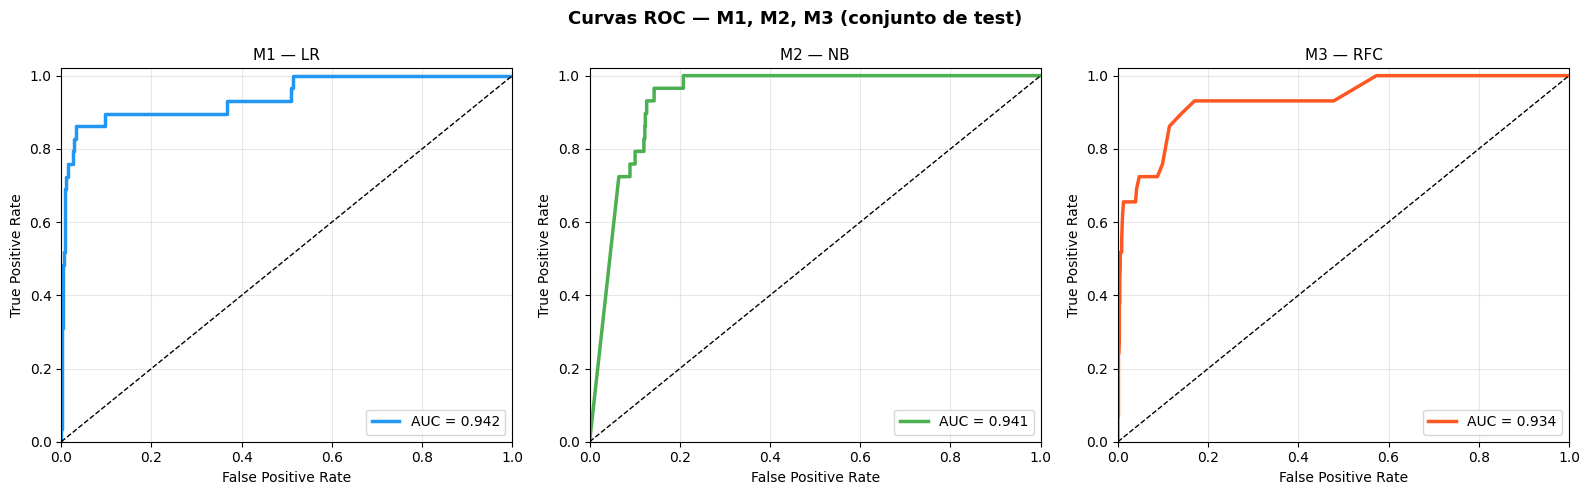

In [31]:
# ─── Curvas ROC comparativas ───────────────────────────────────────────────────
models_eval = [
    ('M1 — LR',  best_m1, X_test_m1, y_test_m1, '#2196F3'),
    ('M2 — NB',  best_m2, X_test_m2, y_test_m2, '#4CAF50'),
    ('M3 — RFC', best_m3, X_test_m3, y_test_m3, '#FF5722'),
]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Curvas ROC — M1, M2, M3 (conjunto de test)', fontsize=13, fontweight='bold')

for ax, (label, model_obj, X_te, y_te, color) in zip(axes, models_eval):
    y_prob = model_obj.predict_proba(X_te)[:, 1]
    fpr, tpr, _ = roc_curve(y_te, y_prob)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, lw=2.5, label=f'AUC = {roc_auc:.3f}')
    ax.plot([0, 1], [0, 1], 'k--', lw=1)
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(label, fontsize=11)
    ax.legend(loc='lower right')
    ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'plots', 'roc_m1_m2_m3.png'), dpi=150, bbox_inches='tight')
plt.show()

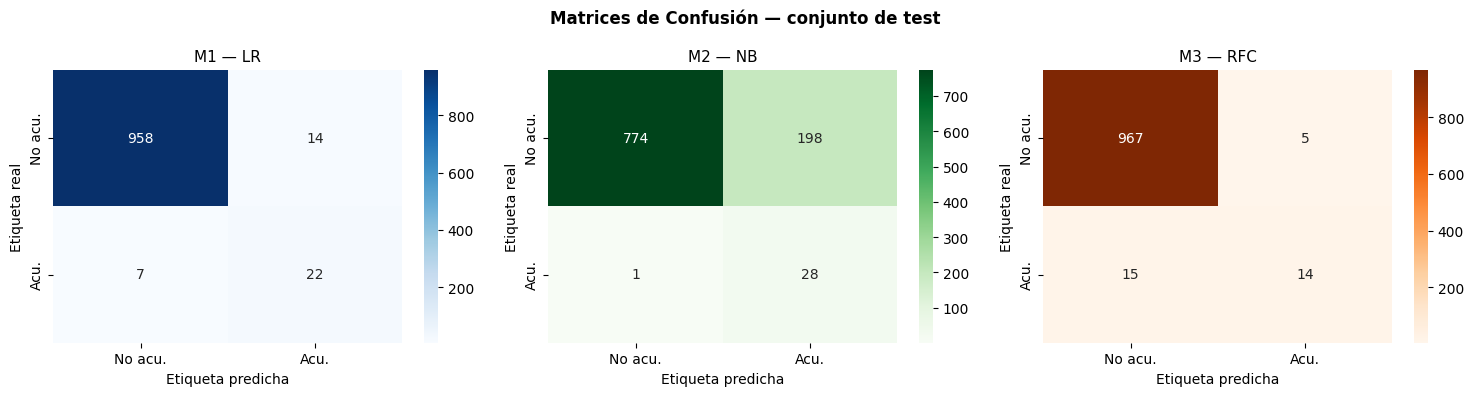

In [32]:
# ─── Matrices de confusión ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Matrices de Confusión — conjunto de test', fontsize=12, fontweight='bold')

labels = ['No acu.', 'Acu.']
for ax, (label, model_obj, X_te, y_te, cmap) in zip(axes, [
    ('M1 — LR',  best_m1, X_test_m1, y_test_m1, 'Blues'),
    ('M2 — NB',  best_m2, X_test_m2, y_test_m2, 'Greens'),
    ('M3 — RFC', best_m3, X_test_m3, y_test_m3, 'Oranges'),
]):
    y_pred = model_obj.predict(X_te)
    cm = confusion_matrix(y_te, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, ax=ax,
                xticklabels=labels, yticklabels=labels)
    ax.set_title(label, fontsize=11)
    ax.set_ylabel('Etiqueta real')
    ax.set_xlabel('Etiqueta predicha')

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'plots', 'cm_m1_m2_m3.png'), dpi=150, bbox_inches='tight')
plt.show()

In [33]:
# ─── Resumen de parámetros óptimos obtenidos ──────────────────────────────────
print('=' * 65)
print('PARÁMETROS ÓPTIMOS OBTENIDOS (GridSearchCV)')
print('=' * 65)
print(f'M1 (LR)  : {best_params_m1}')
print(f'M2 (NB)  : {best_params_m2}')
print(f'M3 (RFC) : {best_params_m3}')
print()
print('PARÁMETROS ÓPTIMOS DE REFERENCIA (Roh López 2024)')
print(f'M1 (LR)  : {{"C": 100, "penalty": "l2", "solver": "saga"}}')
print(f'M2 (NB)  : {{"var_smoothing": 0.35111917342151305}}')
print(f'M3 (RFC) : {{"max_depth": None, "min_samples_leaf": 1, "n_estimators": 200}}')
print()
print(f'Resultados guardados en: {OUTPUT_FILE}')

PARÁMETROS ÓPTIMOS OBTENIDOS (GridSearchCV)
M1 (LR)  : {'C': 100, 'penalty': 'l2', 'solver': 'saga'}
M2 (NB)  : {'var_smoothing': np.float64(0.3511191734215131)}
M3 (RFC) : {'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 80}

PARÁMETROS ÓPTIMOS DE REFERENCIA (Roh López 2024)
M1 (LR)  : {"C": 100, "penalty": "l2", "solver": "saga"}
M2 (NB)  : {"var_smoothing": 0.35111917342151305}
M3 (RFC) : {"max_depth": None, "min_samples_leaf": 1, "n_estimators": 200}

Resultados guardados en: C:\Users\martin\Documents\proyecto_integrador\entregable_2\pipelines\output_replica\results_summary_replica.csv


In [34]:
# ─── Leer y mostrar el CSV de resultados final ─────────────────────────────────
results_final = pd.read_csv(OUTPUT_FILE)

cols_show = ['dataset', 'model', 'embedding', 'ROC_area',
             'test_recall', 'test_precision', 'test_f1', 'test_acc',
             'TP', 'FN', 'FP', 'TN',
             'val_f1', 'train_f1', 'best_params']

print('=== Resultados guardados en results_summary_replica.csv ===')
print(results_final[[c for c in cols_show if c in results_final.columns]].to_string(index=False))

=== Resultados guardados en results_summary_replica.csv ===
                                  dataset                    model              embedding  ROC_area  test_recall  test_precision  test_f1  test_acc  TP  FN  FP  TN   val_f1  train_f1                                                     best_params
                 balanced_total_sinonimos      Logistic_Regression text-embedding-3-large  0.941855     0.758621        0.611111 0.676923  0.979021  22   7  14 958 0.988764  1.000000                   {'C': 100, 'penalty': 'l2', 'solver': 'saga'}
                     total_augmented_data              Naive_Bayes text-embedding-3-large  0.939141     0.965517        0.148148 0.256881  0.838162  28   1 161 811 0.979909  0.978528              {'var_smoothing': np.float64(0.12328467394420659)}
balanced_total_sentence_prompt_GPT4o_mini Random_Forest_Classifier text-embedding-3-large  0.950422     0.482759        0.700000 0.571429  0.979021  14  15   6 966 0.993324  1.000000 {'max_depth': No